In [5]:
pip install matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


# 📊 Module 4: Evidence Detection

Detect verifiable evidence in ESG claims:
- **KPI**: Quantitative metrics
- **Standard**: GRI, SBTi, ISO, SDG
- **Time-bound**: Specific time references
- **Third-party**: External verification
- **Initiative**: Named programs

In [6]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

from evidence.detector import (
    detect_evidence, process_dataframe, 
    EVIDENCE_TYPES, WEIGHT_CONFIGS, calculate_strength
)

# Paths
INPUT_PATH = Path("../data/corpus/esg_sentences_with_actionability.parquet")
OUTPUT_PATH = Path("../data/corpus/esg_sentences_with_evidence.parquet")

print("Evidence Types:")
for name, pattern in EVIDENCE_TYPES.items():
    print(f"  {name}: weight={pattern.weight}")

Evidence Types:
  KPI: weight=0.35
  Standard: weight=0.2
  Time_bound: weight=0.15
  Third_party: weight=0.25
  Initiative: weight=0.05


## 1️⃣ Load Data

In [7]:
df = pd.read_parquet(INPUT_PATH)
print(f"Total ESG sentences: {len(df):,}")
print(f"\nActionability distribution:")
print(df["action_label"].value_counts())

Total ESG sentences: 40,372

Actionability distribution:
action_label
Indeterminate    28933
Implemented      10379
Planning          1060
Name: count, dtype: int64


## 2️⃣ Run Evidence Detection

In [8]:
# Process all sentences
df = process_dataframe(df)

print(f"\n✅ Evidence detection complete!")
print(f"Sentences with evidence: {df['has_evidence'].sum():,} ({df['has_evidence'].mean()*100:.1f}%)")

Processing 40,372 sentences...

✅ Evidence detection complete!
Sentences with evidence: 13,486 (33.4%)


## 3️⃣ Evidence Distribution

KPI              3,100  (  7.7%)
Standard         2,499  (  6.2%)
Time_bound       5,033  ( 12.5%)
Third_party      2,007  (  5.0%)
Initiative       4,509  ( 11.2%)


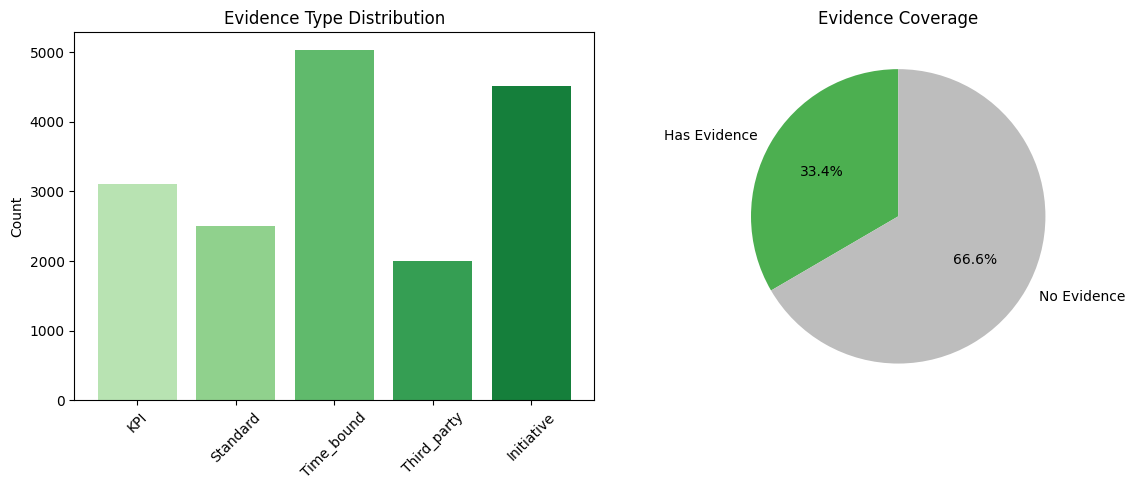

In [9]:
# Count by evidence type
type_counts = {}
for etype in EVIDENCE_TYPES.keys():
    count = df["evidence_types"].apply(lambda x: etype in x).sum()
    pct = count / len(df) * 100
    type_counts[etype] = count
    print(f"{etype:15} {count:>6,}  ({pct:5.1f}%)")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
colors = plt.cm.Greens(np.linspace(0.3, 0.8, 5))
axes[0].bar(type_counts.keys(), type_counts.values(), color=colors)
axes[0].set_title("Evidence Type Distribution")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=45)

# Pie: with vs without evidence
ev_counts = [df['has_evidence'].sum(), (~df['has_evidence']).sum()]
axes[1].pie(ev_counts, labels=['Has Evidence', 'No Evidence'], autopct='%1.1f%%',
            colors=['#4CAF50', '#BDBDBD'], startangle=90)
axes[1].set_title("Evidence Coverage")

plt.tight_layout()
plt.show()

## 4️⃣ 🔑 Cross-Tab: Actionability × Evidence

**This is the KEY analysis for substantive vs symbolic disclosure.**

In [10]:
# Create cross-tab
crosstab = pd.crosstab(
    df["action_label"],
    df["has_evidence"],
    margins=True,
    margins_name="Total"
)
crosstab.columns = ["No Evidence", "Has Evidence", "Total"]

# Add percentages
crosstab_pct = pd.crosstab(
    df["action_label"],
    df["has_evidence"],
    normalize="index"
) * 100
crosstab_pct.columns = ["No Ev %", "Has Ev %"]

result = crosstab.join(crosstab_pct.round(1))
print("=" * 60)
print("CROSS-TAB: ACTIONABILITY × EVIDENCE")
print("=" * 60)
print(result)

CROSS-TAB: ACTIONABILITY × EVIDENCE
               No Evidence  Has Evidence  Total  No Ev %  Has Ev %
action_label                                                      
Implemented           3761          6618  10379     36.2      63.8
Indeterminate        22693          6240  28933     78.4      21.6
Planning               432           628   1060     40.8      59.2
Total                26886         13486  40372      NaN       NaN


In [11]:
# Key insights
print("\n📊 KEY INSIGHTS FOR PAPER:")
print("="*50)

impl_ev = len(df[(df["action_label"] == "Implemented") & (df["has_evidence"] == True)])
impl_no = len(df[(df["action_label"] == "Implemented") & (df["has_evidence"] == False)])
indet_ev = len(df[(df["action_label"] == "Indeterminate") & (df["has_evidence"] == True)])
indet_no = len(df[(df["action_label"] == "Indeterminate") & (df["has_evidence"] == False)])

print(f"✓ Substantive (Implemented + Evidence):     {impl_ev:>6,}")
print(f"⚠ Weak claims (Implemented + No Evidence): {impl_no:>6,}")
print(f"? Ambiguous (Indeterminate + Evidence):    {indet_ev:>6,}")
print(f"🚨 High risk (Indeterminate + No Evidence): {indet_no:>6,}")


📊 KEY INSIGHTS FOR PAPER:
✓ Substantive (Implemented + Evidence):      6,618
⚠ Weak claims (Implemented + No Evidence):  3,761
? Ambiguous (Indeterminate + Evidence):     6,240
🚨 High risk (Indeterminate + No Evidence): 22,693


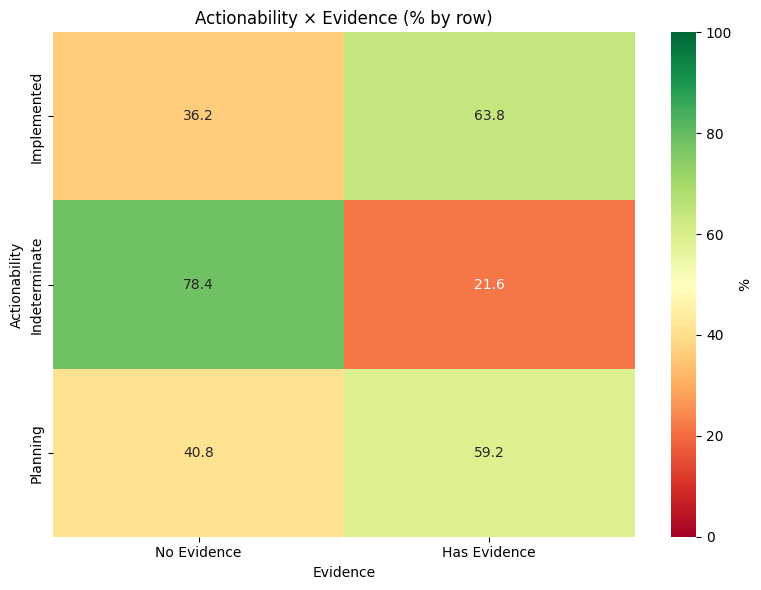

In [12]:
# Visualization: Heatmap
plt.figure(figsize=(8, 6))

heatmap_data = pd.crosstab(df["action_label"], df["has_evidence"], normalize="index") * 100
heatmap_data.columns = ["No Evidence", "Has Evidence"]

sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="RdYlGn", 
            cbar_kws={"label": "%"}, vmin=0, vmax=100)
plt.title("Actionability × Evidence (% by row)")
plt.xlabel("Evidence")
plt.ylabel("Actionability")
plt.tight_layout()
plt.show()

## 5️⃣ Sensitivity Analysis

Test stability of rankings across different weight configurations.

In [13]:
# Calculate strength for each config
print("Weight Configurations:")
for config_name, weights in WEIGHT_CONFIGS.items():
    col_name = f"strength_{config_name}"
    df[col_name] = df["evidence_types"].apply(
        lambda x: calculate_strength(x, config_name) if isinstance(x, list) else 0.0
    )
    print(f"  {config_name}: {weights}")

Weight Configurations:
  default: {'KPI': 0.35, 'Standard': 0.2, 'Time_bound': 0.15, 'Third_party': 0.25, 'Initiative': 0.05}
  kpi_heavy: {'KPI': 0.45, 'Standard': 0.15, 'Time_bound': 0.15, 'Third_party': 0.2, 'Initiative': 0.05}
  uniform: {'KPI': 0.2, 'Standard': 0.2, 'Time_bound': 0.2, 'Third_party': 0.2, 'Initiative': 0.2}
  verif_heavy: {'KPI': 0.3, 'Standard': 0.15, 'Time_bound': 0.1, 'Third_party': 0.4, 'Initiative': 0.05}


In [14]:
# Aggregate by bank-year
strength_cols = [f"strength_{c}" for c in WEIGHT_CONFIGS.keys()]

bank_year = df.groupby(["bank", "year"]).agg({
    **{col: "mean" for col in strength_cols},
    "has_evidence": "mean"
}).reset_index()

bank_year.columns = ["bank", "year"] + [c.replace("strength_", "") for c in strength_cols] + ["ev_rate"]

print("\nBank-Year Evidence Strength (mean):")
print(bank_year.round(3).to_string(index=False))


Bank-Year Evidence Strength (mean):
       bank  year  default  kpi_heavy  uniform  verif_heavy  ev_rate
   agribank  2020    0.094      0.099    0.099        0.080    0.364
   agribank  2021    0.090      0.098    0.093        0.075    0.347
   agribank  2022    0.101      0.106    0.101        0.091    0.418
   agribank  2023    0.096      0.099    0.103        0.087    0.373
   agribank  2024    0.090      0.094    0.112        0.079    0.420
       bidv  2020    0.087      0.090    0.098        0.075    0.373
       bidv  2021    0.082      0.087    0.094        0.071    0.362
       bidv  2022    0.075      0.076    0.095        0.067    0.369
       bidv  2023    0.077      0.077    0.096        0.070    0.374
       bidv  2024    0.083      0.084    0.103        0.076    0.386
        bsc  2020    0.003      0.003    0.006        0.003    0.028
        bsc  2021    0.059      0.059    0.061        0.062    0.257
        bsc  2022    0.048      0.048    0.054        0.048    0.2

In [15]:
# Ranking stability (Spearman correlation)
print("\n" + "="*50)
print("RANKING STABILITY (Spearman correlation)")
print("="*50)

config_names = list(WEIGHT_CONFIGS.keys())
corr_matrix = np.zeros((len(config_names), len(config_names)))

for i, c1 in enumerate(config_names):
    for j, c2 in enumerate(config_names):
        corr, _ = spearmanr(bank_year[c1], bank_year[c2])
        corr_matrix[i, j] = corr

corr_df = pd.DataFrame(corr_matrix, index=config_names, columns=config_names).round(3)
print(corr_df)

print("\n✅ High correlations (>0.9) indicate ranking stability across weight choices.")


RANKING STABILITY (Spearman correlation)
             default  kpi_heavy  uniform  verif_heavy
default        1.000      0.993    0.930        0.940
kpi_heavy      0.993      1.000    0.929        0.924
uniform        0.930      0.929    1.000        0.875
verif_heavy    0.940      0.924    0.875        1.000

✅ High correlations (>0.9) indicate ranking stability across weight choices.


## 6️⃣ Evidence by ESG Topic

In [16]:
# Evidence rate by topic
topic_ev = df.groupby("predicted_label").agg({
    "has_evidence": ["sum", "count", "mean"],
    "evidence_strength": "mean"
}).round(3)

topic_ev.columns = ["with_evidence", "total", "evidence_rate", "avg_strength"]
print("Evidence by ESG Topic:")
print(topic_ev)

Evidence by ESG Topic:
                 with_evidence  total  evidence_rate  avg_strength
predicted_label                                                   
E                         2076   3545          0.586         0.110
G                         5375  17888          0.300         0.070
S_community               1183   2915          0.406         0.089
S_labor                   2179   7578          0.288         0.063
S_product                 2673   8446          0.316         0.082


In [17]:
# Evidence type by Actionability
print("\nEvidence Types by Actionability:")
for action in ["Implemented", "Planning", "Indeterminate"]:
    subset = df[df["action_label"] == action]
    print(f"\n  {action} (n={len(subset):,}):")
    for etype in EVIDENCE_TYPES.keys():
        count = subset["evidence_types"].apply(lambda x: etype in x).sum()
        pct = count / len(subset) * 100 if len(subset) > 0 else 0
        print(f"    {etype:15} {count:>5}  ({pct:5.1f}%)")


Evidence Types by Actionability:

  Implemented (n=10,379):
    KPI              2473  ( 23.8%)
    Standard         1051  ( 10.1%)
    Time_bound       3510  ( 33.8%)
    Third_party       675  (  6.5%)
    Initiative       1623  ( 15.6%)

  Planning (n=1,060):
    KPI                80  (  7.5%)
    Standard           93  (  8.8%)
    Time_bound        459  ( 43.3%)
    Third_party        36  (  3.4%)
    Initiative        213  ( 20.1%)

  Indeterminate (n=28,933):
    KPI               547  (  1.9%)
    Standard         1355  (  4.7%)
    Time_bound       1064  (  3.7%)
    Third_party      1296  (  4.5%)
    Initiative       2673  (  9.2%)


## 7️⃣ Save Results

In [18]:
# Save main output
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
df.to_parquet(OUTPUT_PATH, index=False)
print(f"✅ Saved: {OUTPUT_PATH}")

# Save analysis tables
OUTPUT_DIR = Path("../outputs/evidence_analysis")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

result.to_csv(OUTPUT_DIR / "crosstab_action_evidence.csv")
bank_year.to_csv(OUTPUT_DIR / "sensitivity_bank_year.csv", index=False)
topic_ev.to_csv(OUTPUT_DIR / "evidence_by_topic.csv")

print(f"✅ Saved analysis to: {OUTPUT_DIR}")

✅ Saved: ../data/corpus/esg_sentences_with_evidence.parquet
✅ Saved analysis to: ../outputs/evidence_analysis


## 8️⃣ Sample Predictions

In [19]:
# Show examples
for has_ev in [True, False]:
    label = "WITH" if has_ev else "WITHOUT"
    print(f"\n{'='*60}")
    print(f"EXAMPLES {label} EVIDENCE")
    print("="*60)
    
    samples = df[df["has_evidence"] == has_ev].sample(n=min(3, len(df)), random_state=42)
    for _, row in samples.iterrows():
        print(f"\n📝 {row['sentence'][:150]}..." if len(row['sentence']) > 150 else f"\n📝 {row['sentence']}")
        print(f"   Action: {row['action_label']} | Topic: {row['predicted_label']}")
        if has_ev:
            print(f"   Evidence: {row['evidence_types']} | Strength: {row['evidence_strength']:.2f}")


EXAMPLES WITH EVIDENCE

📝 Ngân hàng đo lường rủi ro lãi suất đối với VND và ngoại tệ có giá trị từ 5% tổng tài sản trở lên thông qua các phương pháp và chỉ số như: Gap nhạy cảm...
   Action: Implemented | Topic: G
   Evidence: ['KPI'] | Strength: 0.35

📝 Nụ cười BIDV nhằm xây dựng hình ảnh người giao dịch viên/cán bộ BIDV Chu đáo – Chuyên nghiệp – Chất lượng thông qua nhiều hoạt động phong trào và truy...
   Action: Indeterminate | Topic: S_labor
   Evidence: ['Initiative'] | Strength: 0.05

📝 CHỈ SỐ ĐO LƯỜNG SỰ HÀI LÒNG KHÁCH HÀNG CSAT = 97%
   Action: Implemented | Topic: E
   Evidence: ['KPI'] | Strength: 0.35

EXAMPLES WITHOUT EVIDENCE

📝 TIẾP TỤC NÂNG CẤP HỆ THỐNG TUYỂN DỤNG
   Action: Indeterminate | Topic: S_community

📝 Thành viên Ủy ban
   Action: Indeterminate | Topic: G

📝 - Được khẳng ịnh năng lực ể ề bạt, bổ nhiệm, ược ánh giá ể thưởng thành tích.
   Action: Indeterminate | Topic: S_labor


## 📊 Summary

In [20]:
print("="*60)
print("MODULE 4 COMPLETE")
print("="*60)
print(f"Total ESG sentences: {len(df):,}")
print(f"With evidence: {df['has_evidence'].sum():,} ({df['has_evidence'].mean()*100:.1f}%)")
print(f"\nSubstantive (Implemented + Evidence): {impl_ev:,}")
print(f"High risk (Indeterminate + No Evidence): {indet_no:,}")
print(f"\nOutputs:")
print(f"  - {OUTPUT_PATH}")
print(f"  - {OUTPUT_DIR}/")

MODULE 4 COMPLETE
Total ESG sentences: 40,372
With evidence: 13,486 (33.4%)

Substantive (Implemented + Evidence): 6,618
High risk (Indeterminate + No Evidence): 22,693

Outputs:
  - ../data/corpus/esg_sentences_with_evidence.parquet
  - ../outputs/evidence_analysis/
